# Crossover / Intersection Between Two Sequences

## Algorithm

1. **Generate one random origin pattern**, $\xi^0$. This is *not* done by
   `KuramotoNetwork` -- the network only owns config/omega/simulate/diagnostics;
   pattern generation lives in free functions (`generate_sequence`, `corrupt_phase`),
   independent of the network object.
2. **Draw 4 seeds at random** from a seed pool (a fresh draw every trial, not fixed).
3. **Mutate the origin independently 4 times**, one per seed (each mutation is its own
   fresh corruption of $\xi^0$, not chained from one another). Build two length-3
   sequences with the origin as the shared centre pattern:
   $$A: M_1 \rightarrow \xi^0 \rightarrow M_2 \qquad B: M_3 \rightarrow \xi^0 \rightarrow M_4$$
4. **Combine A and B into one `MultiSequence`** and run `simulate()` on it.
   A `MultiSequence` takes its own code path: `_integrate` pulls the rectangular
   $(K, P, N)$ pair `xi_tensor()`/`xi_next_tensor()`, which puts the sequence index
   $a$ on its own axis, and dispatches to the multi-sequence kernels
   (`_simulate_euler_multi` / `_simulate_maruyama_multi`), whose drive sums over
   $(a, \mu)$ rather than over $\mu$ alone. Being rectangular, it requires every
   member to store the same number of patterns -- here A and B both hold 3.
   Successors are resolved *within* each sequence before stacking, so A's chain never
   points into B's. But the drive on every neuron sums over all $K \times P$ stored
   patterns regardless of which sequence they came from, so A and B do interfere --
   that shared interference is what this experiment measures. (The flat
   `MultiSequence.xi()`/`.xi_next()` concatenations still exist, but only the
   diagnostics use them: `overlaps`, `labels`, the decoders and `plot`.)
5. **Repeat for `M` independent trials** (fresh random seeds each time). Each trial
   runs two simulations -- one cued from $A[0]$, one from $B[0]$ -- with nonzero
   `frequency_std` (omega must be present, or the exact-cue degeneracy freezes the
   dynamics -- see earlier findings this session). Plot the overlap and the
   per-sequence overlap breakdown for both. Decode with `decode_sequence_online`,
   take only the first 3 retrieved labels ("cut at 3"), and score +1 if they exactly
   match that sequence's own expected order, else 0. Print the average success rate
   across all `2*M` cueing attempts.

In [29]:
%load_ext autoreload
%autoreload 2

import numpy as np

import kuramoto_library2 as krm

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.4,
    mode="ode",
)

N = 100
M = 5 # number of trials
MARGIN = 0.01
SEED_POOL = 10_000
master_rng = np.random.default_rng(0)

## Build one crossover trial

In [37]:
def make_crossover_multisequence(N, corruption_rate, origin_seed, mutation_seeds):
    rng = np.random.default_rng(origin_seed)
    origin = rng.choice([0.0, np.pi], size=N) # this is the origin and crossover pattern

    M1, M2, M3, M4 = [
        krm.corrupt_phase(origin, corruption_rate, np.random.default_rng(s))
        for s in mutation_seeds
    ]

    multi = krm.MultiSequence()
    multi.add(krm.sequence_from_patterns("A", [M1, origin, M2]))
    multi.add(krm.sequence_from_patterns("B", [M3, origin, M4]))
    return multi



def run_trial(net, rng):
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=4, replace=False).tolist()
    multi = make_crossover_multisequence(N, CONFIG["corruption_rate"], origin_seed, mutation_seeds)

    result_A = net.simulate(multi, cue=multi["A"], cue_idx=0)
    result_B = net.simulate(multi, cue=multi["B"], cue_idx=0)

    retrieved_A = net.decode_sequence_online(result_A, multi, margin=MARGIN)[:3]
    retrieved_B = net.decode_sequence_online(result_B, multi, margin=MARGIN)[:3]

    success_A = (len(retrieved_A) > 2 and retrieved_A[2] == multi["A"].labels()[2])
    success_B = (len(retrieved_B) > 2 and retrieved_B[2] == multi["B"].labels()[2])

    return multi, result_A, result_B, retrieved_A, retrieved_B, success_A, success_B

## Run M trials

trial 0: A retrieved=[('A', 0), ('A', 1), ('B', 2)] success=False
trial 0: B retrieved=[('B', 0), ('A', 1), ('A', 2)] success=False


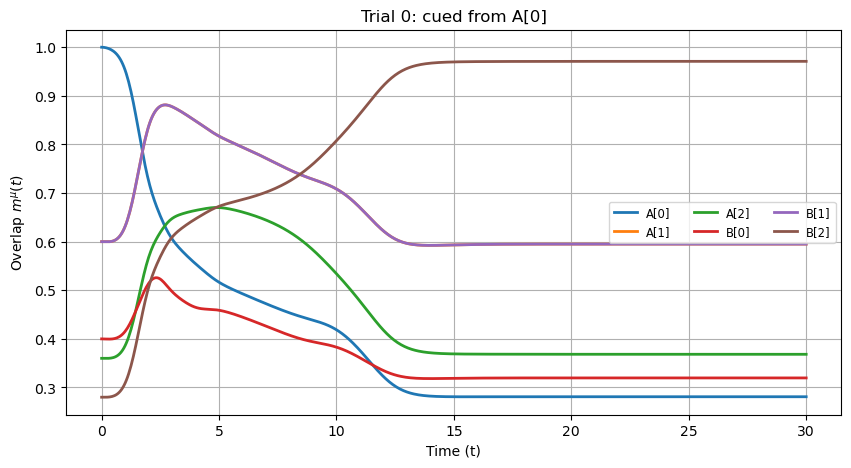

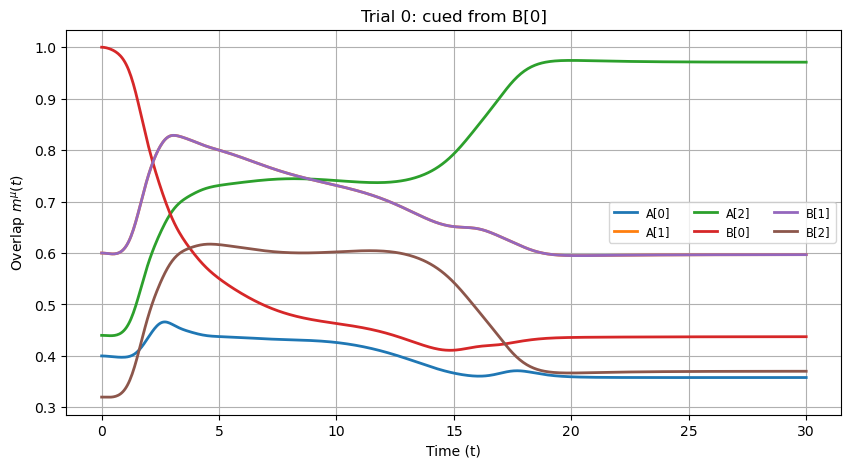

trial 1: A retrieved=[('A', 0), ('A', 1), ('B', 2)] success=False
trial 1: B retrieved=[('B', 0), ('A', 1), ('A', 2)] success=False


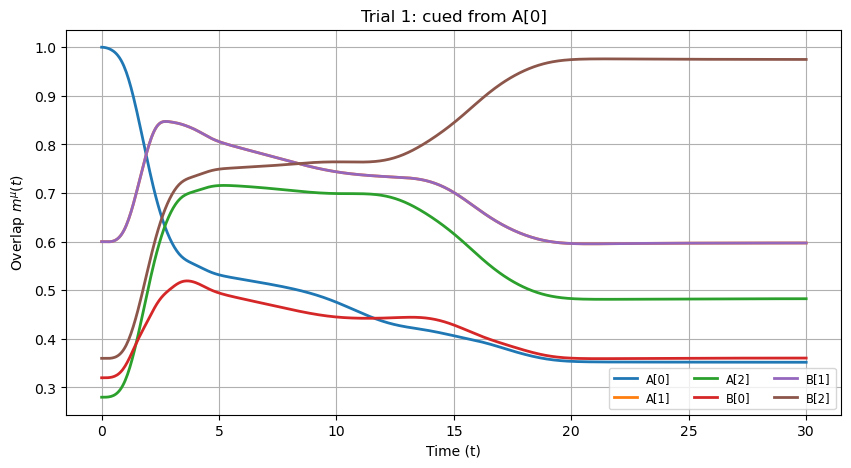

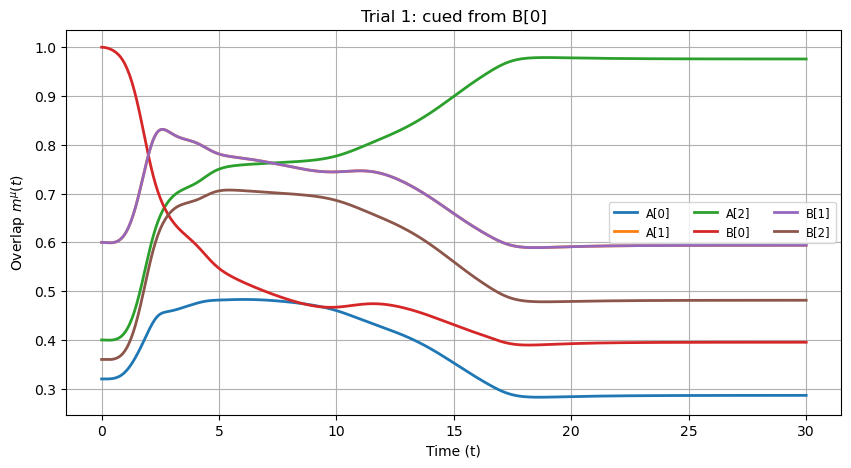

trial 2: A retrieved=[('A', 0), ('A', 1), ('A', 2)] success=True
trial 2: B retrieved=[('B', 0), ('A', 1), ('A', 2)] success=False


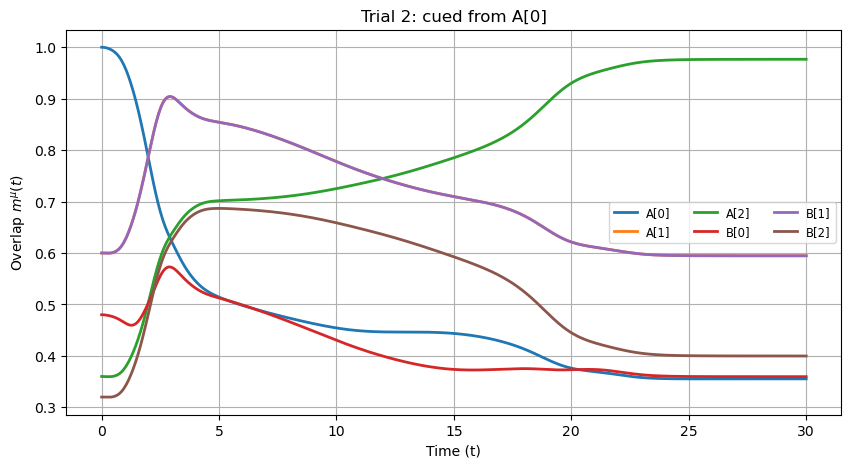

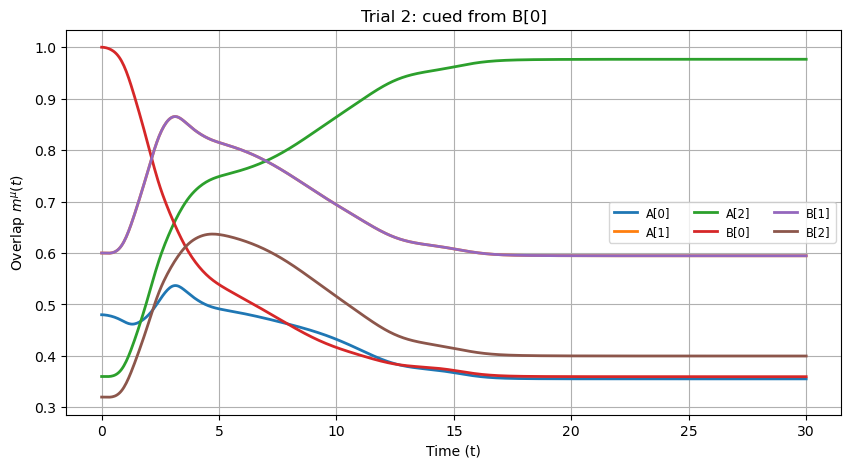

trial 3: A retrieved=[('A', 0), ('A', 1), ('B', 2)] success=False
trial 3: B retrieved=[('B', 0), ('A', 1), ('B', 2)] success=True


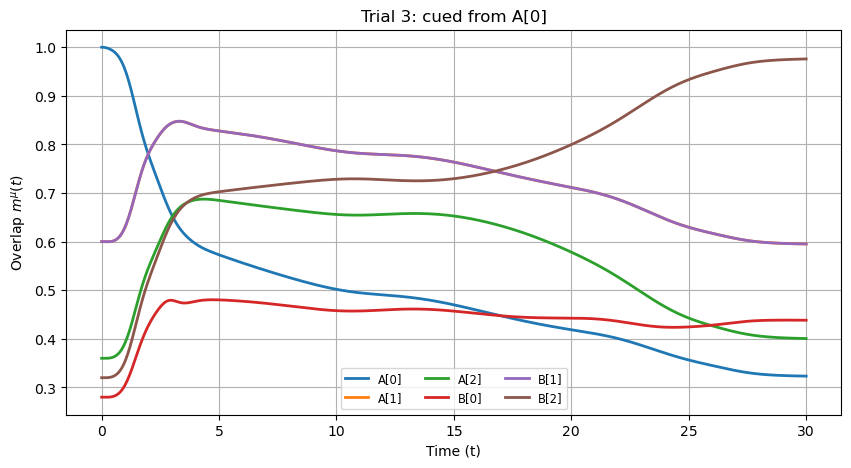

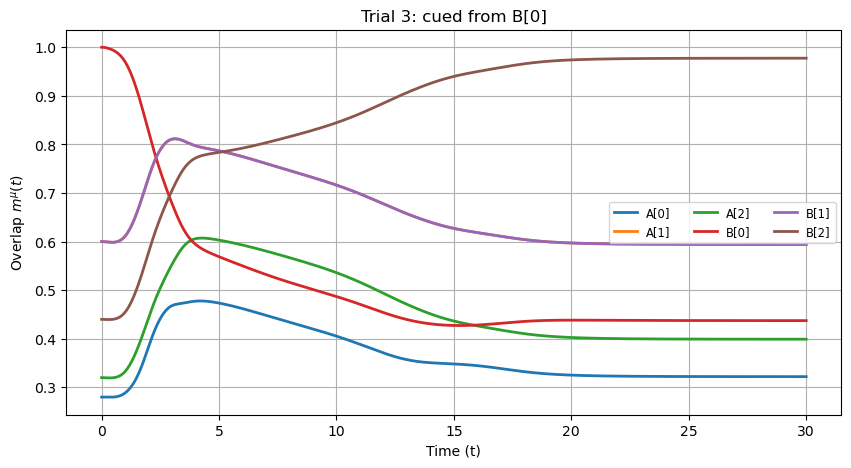

trial 4: A retrieved=[('A', 0), ('A', 1), ('B', 2)] success=False
trial 4: B retrieved=[('B', 0), ('A', 1), ('B', 2)] success=True


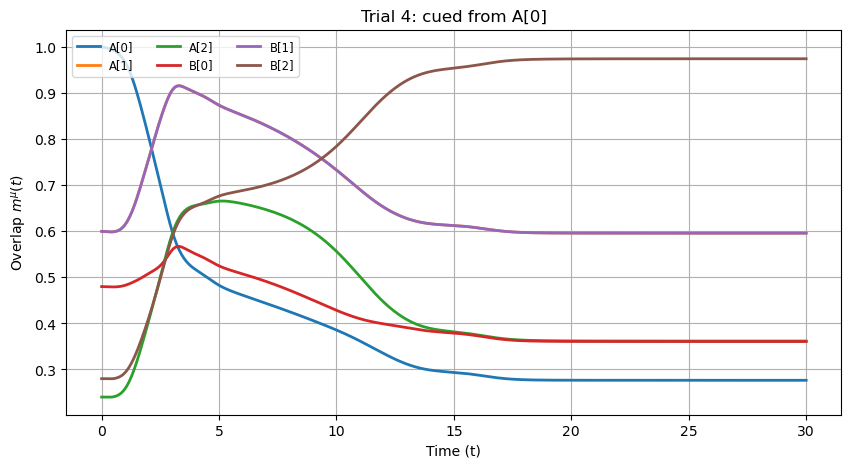

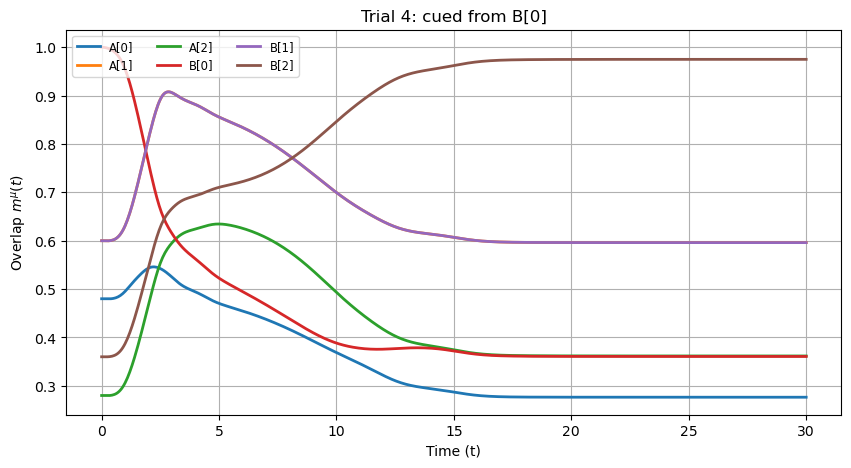

average success rate: 0.3


In [ ]:
net = krm.KuramotoNetwork(N=N, seed=10, **CONFIG)

successes = []
for trial in range(M):
    multi, result_A, result_B, retrieved_A, retrieved_B, success_A, success_B = run_trial(net, master_rng)
    successes += [success_A, success_B]

    print(f"trial {trial}: A retrieved={retrieved_A} success={success_A}")
    print(f"trial {trial}: B retrieved={retrieved_B} success={success_B}")

    # net.plot(result_A, multi, title=f"Trial {trial}: cued from A[0]")
    # net.plot(result_B, multi, title=f"Trial {trial}: cued from B[0]")


print("average success rate:", sum(successes) / len(successes))

# A1 and B1 are the exact same pattern, cross over

## Learning Rules

Redefining the _integrate method via inheritance

1) i+2 instead of i+1